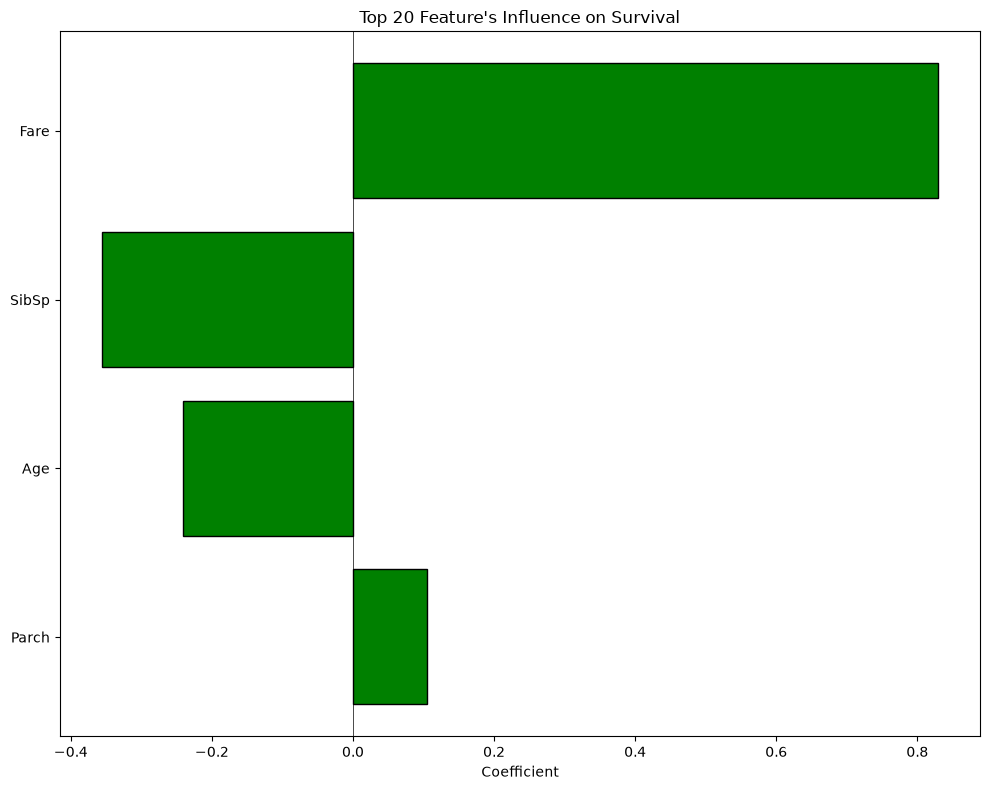

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# 1. 데이터 로드
df_train = pd.read_csv("datasets/titanic/train.csv")
df_test = pd.read_csv("datasets/titanic/test.csv")

# 2. 전처리: 결측치 채우기 (inplace=True 대신 직접 할당 사용)
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())
df_train['Fare'] = df_train['Fare'].fillna(df_train['Fare'].median())
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])

# 타이타닉 데이터셋의 기본 성별 컬럼명은 대개 'Sex'입니다. 만약 'Gender'라면 그대로 두셔도 됩니다.
# 여기서는 일반적인 'Sex' 컬럼명을 고려하되, 코드 안전성을 위해 존재 여부를 체크해 범주형 변환을 합니다.
target_categorical = [col for col in ['Pclass', 'Sex', 'Gender', 'Embarked'] if col in df_train.columns]

# 3. 범주형 변수 더미화 (One-Hot Encoding)
df_train = pd.get_dummies(df_train, columns=target_categorical, drop_first=True)

# 4. 피처 세트(X)와 타겟 변수(y) 정의
# 불필요한 문자열 컬럼 제거
drop_cols = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin']
X = df_train.drop(columns=drop_cols, errors='ignore')
y = df_train['Survived']

# 5. 혹시 모를 수치형 외 컬럼(문자열 등)이 남아있다면 마지막으로 필터링
X = X.select_dtypes(include=[np.number])

# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 로지스틱 회귀 파이프라인 생성
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(max_iter=1000))
])

# 8. 모델 학습 (이제 NaN 에러가 발생하지 않습니다!)
pipeline.fit(X_train, y_train)

# 9. 피처 계수(Coefficients) 추출
cols = X.columns.tolist()
coef = pipeline.named_steps['logisticregression'].coef_[0]
coef_df = pd.DataFrame({'Feature': cols, 'Coefficient': coef})

# 절대값 기준 상위 20개 피처 정렬
top_coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index).head(20)

# 10. 시각화
plt.rcParams['figure.figsize'] = [10, 8]
fig, ax = plt.subplots()
y_pos = np.arange(len(top_coef_df))
ax.barh(y_pos, top_coef_df.Coefficient, align='center', color='green', edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_coef_df['Feature'])
ax.invert_yaxis()  # 가장 영향력 큰 피처를 맨 위로
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient')
ax.set_title("Top 20 Feature's Influence on Survival")

plt.tight_layout()
plt.show()